In [16]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

BASE_DIR = '/home/pedro.campos/Desktop/QML/pee-886-2026-01'
DATA_DIR = os.path.join(BASE_DIR, "data", "pedro_campos")
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

sns.set_theme(style="whitegrid", palette="muted")

In [22]:
import optuna
from data.pedro_campos.config import DB_PATH

# Carrega os estudos do banco de dados
study_mlp = optuna.load_study(study_name="MLP_Baseline", storage=DB_PATH)
study_restrito = optuna.load_study(study_name="MLP_Restricted", storage=DB_PATH)
study_qnn = optuna.load_study(study_name="QNN_Ansatz_FIXED", storage=DB_PATH)

print("=== MLP Irrestrito ===")
print(study_mlp.best_params)

print("\n=== MLP Restrito ===")
print(study_restrito.best_params)

print("\n=== QNN Ansatz ===")
print(study_qnn.best_params)

=== MLP Irrestrito ===
{'n_layers': 3, 'n_neurons': 32, 'lr': 0.0027104439108718986}

=== MLP Restrito ===
{'n_layers': 5, 'lr': 0.0060157259070802915}

=== QNN Ansatz ===
{'n_layers': 1, 'lr': 0.04391263118465519}


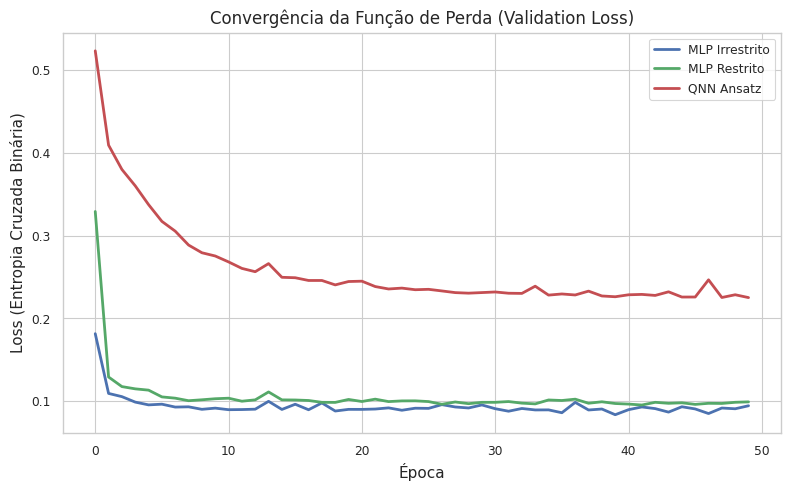

In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Apontando para o diretório correto onde o CSVLogger salvou os testes
LOGS_DIR = os.path.join(BASE_DIR, "data", "pedro_campos", "test_logs")

modelos = {
    "MLP Irrestrito": "mlp_baseline",
    "MLP Restrito": "mlp_restricted",
    "QNN Ansatz": "qnn_ansatz_fixed"
}

sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(8, 5))

cores = {"MLP Irrestrito": "#4C72B0", "MLP Restrito": "#55A868", "QNN Ansatz": "#C44E52"}

for nome_exibicao, nome_pasta in modelos.items():
    # Caminho ajustado para buscar o arquivo metrics.csv dentro da pasta correta
    caminho_csv = os.path.join(LOGS_DIR, nome_pasta, "version_0", "metrics.csv")
    
    if os.path.exists(caminho_csv):
        df = pd.read_csv(caminho_csv)
        # O Lightning pode registrar as métricas em steps diferentes, o groupby alinha tudo por época
        if 'val_loss' in df.columns:
            df_epoch = df.groupby('epoch')['val_loss'].mean().dropna()
            plt.plot(df_epoch.index, df_epoch.values, label=nome_exibicao, lw=2, color=cores[nome_exibicao])
    else:
        print(f"Aviso: Arquivo não encontrado para {nome_exibicao} em {caminho_csv}")

plt.title('Convergência da Função de Perda (Validation Loss)', fontsize=12)
plt.xlabel('Época', fontsize=11)
plt.ylabel('Loss (Entropia Cruzada Binária)', fontsize=11)
plt.legend()
plt.tight_layout()

# Apenas exibe o gráfico no notebook
plt.show()

In [ ]:
DATA_DIR = os.path.join(BASE_DIR, "data", "pedro_campos")
resultados_kfold = []

for nome_exibicao, nome_arquivo in modelos.items():
    caminho_csv = os.path.join(DATA_DIR, f"kfold_{nome_arquivo}.csv")
    if os.path.exists(caminho_csv):
        df_kfold = pd.read_csv(caminho_csv)
        
        media_f1 = df_kfold['val_f1'].mean() * 100
        std_f1 = df_kfold['val_f1'].std() * 100
        media_auc = df_kfold['val_auroc'].mean() * 100
        std_auc = df_kfold['val_auroc'].std() * 100
        resultados_kfold.append({
            "Arquitetura": nome_exibicao,
            "F1-Score Médio (%)": f"{media_f1:.2f}",
            "Desvio Padrão F1 (%)": f"± {std_f1:.2f}",
            "AUC Médio (%)": f"{media_auc:.2f}",
            "Desvio Padrão AUC (%)": f"± {std_auc:.2f}"
        })

df_resultados = pd.DataFrame(resultados_kfold)
print("=== Resultados K-Fold ===")
display(df_resultados)

=== Resultados K-Fold para a Tabela no LaTeX ===


,Arquitetura,F1-Score Médio (%),Desvio Padrão F1 (%),AUC Médio (%),Desvio Padrão AUC (%)
0,MLP Irrestrito,97.15,± 0.28,99.39,± 0.13
1,MLP Restrito,96.96,± 0.37,99.31,± 0.11
2,QNN Ansatz,95.40,± 0.61,98.40,± 0.22


In [30]:
resultados_teste = []

for nome_exibicao, nome_arquivo in modelos.items():
    caminho_csv = os.path.join(DATA_DIR, f"teste_{nome_arquivo}.csv")
    if os.path.exists(caminho_csv):
        df_teste = pd.read_csv(caminho_csv)
        resultados_teste.append({
            "Arquitetura": df_teste['modelo'].iloc[0],
            "F1-Score": f"{df_teste['f1_score'].iloc[0]*100:.2f}",
            "Acuracia": f"{df_teste['accuracy'].iloc[0]*100:.2f}",
            "AUC": f"{df_teste['roc_auc'].iloc[0]:.4f}",
        })

df_resultados = pd.DataFrame(resultados_teste)
print("=== Resultados Teste  ===")
display(df_resultados)

=== Resultados Teste  ===


,Arquitetura,F1-Score,Acuracia,AUC
0,mlp_baseline,97.30,96.48,0.9941
1,mlp_restricted,97.06,96.16,0.9933
2,qnn_ansatz_fixed,93.49,91.59,0.9656


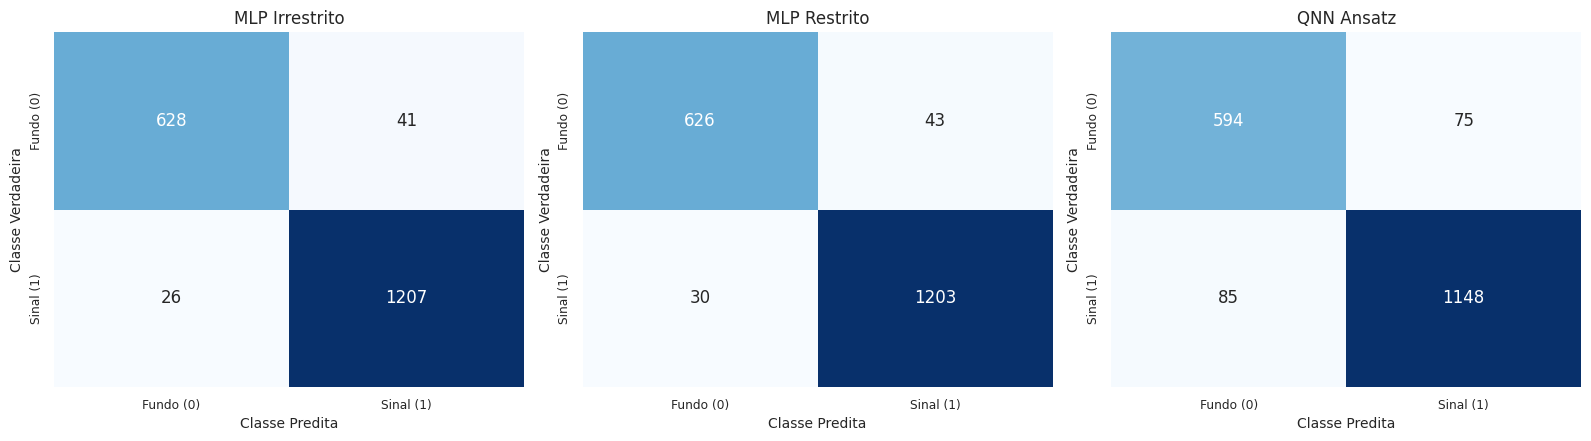

In [32]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes = axes.flatten()

for idx, (nome_exibicao, nome_arquivo) in enumerate(modelos.items()):
    caminho_csv = os.path.join(DATA_DIR, f"predict_{nome_arquivo}.csv")
    if os.path.exists(caminho_csv):
        df_pred = pd.read_csv(caminho_csv)
        y_real = df_pred['y_real']
        y_pred = df_pred['predicao_final']
        
        cm = confusion_matrix(y_real, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                    xticklabels=['Fundo (0)', 'Sinal (1)'], 
                    yticklabels=['Fundo (0)', 'Sinal (1)'],
                    annot_kws={"size": 12}, cbar=False)
        
        axes[idx].set_title(f'{nome_exibicao}', fontsize=12)
        axes[idx].set_xlabel('Classe Predita', fontsize=10)
        axes[idx].set_ylabel('Classe Verdadeira', fontsize=10)

plt.tight_layout()

caminho_matriz_pdf = os.path.join(DATA_DIR, "matrizes_confusao.pdf")
plt.show()

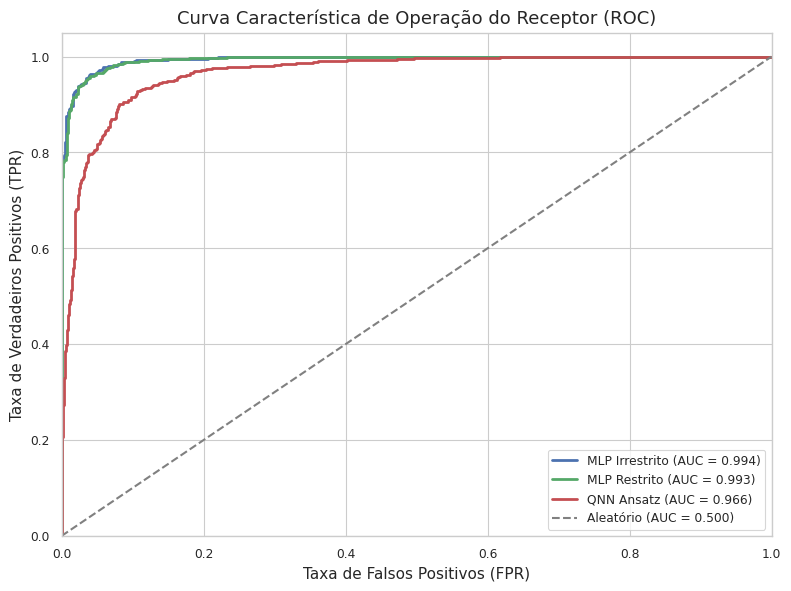

In [31]:
sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(8, 6))

for nome_exibicao, nome_pasta in modelos.items():
    caminho_csv = os.path.join(DATA_DIR, f"predict_{nome_pasta}.csv")
    
    if os.path.exists(caminho_csv):
        df_pred = pd.read_csv(caminho_csv)
        
        y_real = df_pred['y_real']
        probs = df_pred['probabilidade_sinal']
        
        # Cálculo da curva ROC e da AUC
        fpr, tpr, thresholds = roc_curve(y_real, probs)
        roc_auc = auc(fpr, tpr)
        
        # Plot da curva do modelo com a AUC na legenda
        plt.plot(fpr, tpr, color=cores[nome_exibicao], lw=2, 
                 label=f'{nome_exibicao} (AUC = {roc_auc:.3f})')
    else:
        print(f"[*] Arquivo não encontrado: {caminho_csv}")

# Plot da linha de base (classificador aleatório)
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Aleatório (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Curva Característica de Operação do Receptor (ROC)', fontsize=13)
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

# Exibição direta no notebook
plt.show()